# Toxic Comment Classification using Machine Learning & NLP

## Objective

Build a toxic comment classification system capable of detecting multiple categories of toxic language in online comments.

This notebook focuses on:

- Understanding the problem
- Exploring the dataset
- Performing EDA
- Drawing insights before modeling

This project is built using the Jigsaw Toxic Comment Classification dataset from Kaggle.

## Business Problem

Online platforms receive millions of comments every day.

Manual moderation is:
- Slow
- Expensive
- Inconsistent

The objective is to automatically detect toxic comments using Machine Learning.

This is a **Multi-Label Classification** problem because a single comment can belong to multiple toxicity categories simultaneously.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [5]:
train = pd.read_csv("/kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/train.csv")
test = pd.read_csv("/kaggle/input/datasets/julian3833/jigsaw-toxic-comment-classification-challenge/test.csv")

print("Train Shape :", train.shape)
print("Test Shape  :", test.shape)

Train Shape : (159571, 8)
Test Shape  : (153164, 2)


In [6]:
train.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [20]:
train.describe(include="all")

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,num_labels
count,159571,159571,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000
unique,159571,159571,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,fff46fc426af1f9a,"""\nAnd ... I really don't think you understand...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,0.095844,0.009996,0.052948,0.002996,0.049364,0.008805,0.219952
std,NaN,NaN,0.294379,0.099477,0.223931,0.054650,0.216627,0.093420,0.748260
min,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [21]:
train.columns.tolist()

['id',
 'comment_text',
 'toxic',
 'severe_toxic',
 'obscene',
 'threat',
 'insult',
 'identity_hate',
 'num_labels']

## Dataset Columns

- id : Unique identifier
- comment_text : User comment
- toxic
- severe_toxic
- obscene
- threat
- insult
- identity_hate

The last six columns are target labels.

In [11]:
train.isnull().sum()

id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

In [12]:
print("Duplicate Rows :", train.duplicated().sum())

Duplicate Rows : 0


In [22]:
train["comment_text"].duplicated().sum()

np.int64(0)

In [14]:
target_columns = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

target_columns

['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

In [15]:
train[target_columns].sum().sort_values(ascending=False)

toxic            15294
obscene           8449
insult            7877
severe_toxic      1595
identity_hate     1405
threat             478
dtype: int64

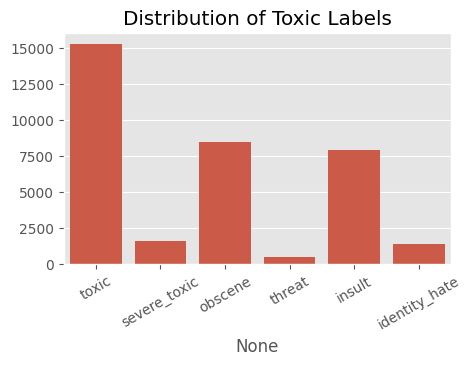

In [23]:
plt.figure(figsize=(5,3))

sns.barplot(
    x=train[target_columns].sum().index,
    y=train[target_columns].sum().values
)

plt.title("Distribution of Toxic Labels")
plt.xticks(rotation=30)
plt.show()

In [17]:
train["num_labels"] = train[target_columns].sum(axis=1)

train["num_labels"].value_counts().sort_index()

num_labels
0    143346
1      6360
2      3480
3      4209
4      1760
5       385
6        31
Name: count, dtype: int64

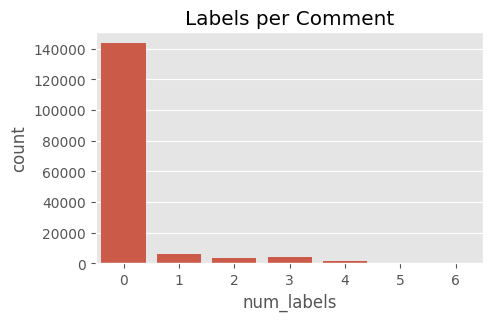

In [24]:
plt.figure(figsize=(5,3))

sns.countplot(x=train["num_labels"])

plt.title("Labels per Comment")
plt.show()

In [26]:
# Percentage of clean comments
clean_percentage = (train["num_labels"] == 0).mean() * 100

print(f"Clean Comments : {clean_percentage:.2f}%")

Clean Comments : 89.83%


In [27]:
# Comment Length Analysis

train["char_length"] = train["comment_text"].str.len()
train["word_count"] = train["comment_text"].str.split().apply(len)

In [28]:
train[["char_length","word_count"]].describe()

,char_length,word_count
count,159571.000000,159571.000000
mean,394.073221,67.273527
std,590.720282,99.230702
min,6.000000,1.000000
25%,96.000000,17.000000
50%,205.000000,36.000000
75%,435.000000,75.000000
max,5000.000000,1411.000000


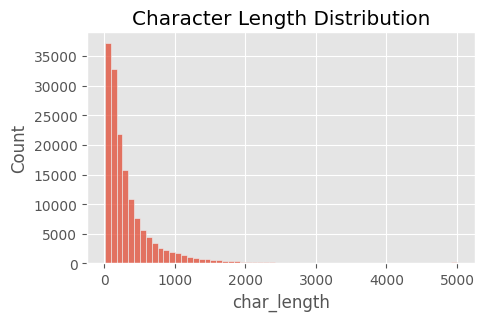

In [29]:
plt.figure(figsize=(5,3))
sns.histplot(train["char_length"], bins=60)
plt.title("Character Length Distribution")
plt.show()

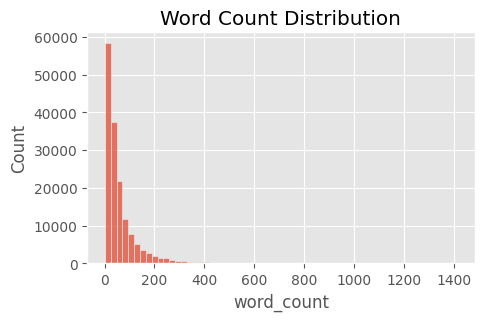

In [30]:
plt.figure(figsize=(5,3))
sns.histplot(train["word_count"], bins=60)
plt.title("Word Count Distribution")
plt.show()

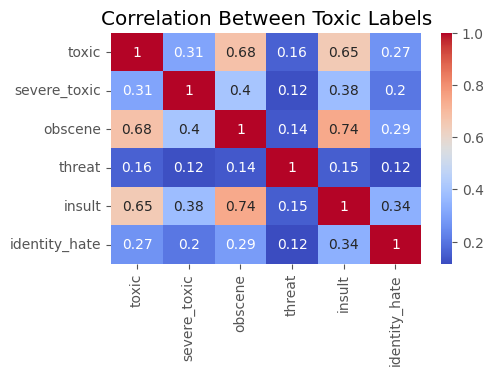

In [33]:
# Correlation among labels

plt.figure(figsize=(5,3))

sns.heatmap(
    train[target_columns].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Toxic Labels")

plt.show()

# Key Observations

- Checked for missing values.
- Checked duplicate records.
- Studied class imbalance.
- Measured comment lengths.
- Compared clean vs toxic comments.
- Observed correlations among target labels.